<a href="https://colab.research.google.com/github/filipsajtlava/dspracticum2025-tismaci/blob/master/homeworks/hw2/CNN_own_data_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Where's the data fetching?

the data fetching is done locally through the code on our [GitHub](https://github.com/filipsajtlava/dspracticum2025-tismaci/blob/master/homeworks/hw2/fetch_and_save_data.ipynb). It is also entirely possible to run it in colab, but it does not seem to be any quicker, so the simpler way is to just clone it from the repo.

In [1]:
!git clone https://github.com/filipsajtlava/dspracticum2025-tismaci

Cloning into 'dspracticum2025-tismaci'...
remote: Enumerating objects: 2015, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 2015 (delta 9), reused 7 (delta 2), pack-reused 1993 (from 1)
Receiving objects: 100% (2015/2015), 368.04 MiB | 44.71 MiB/s, done.
Resolving deltas: 100% (20/20), done.


In [2]:
%cd dspracticum2025-tismaci/

/content/dspracticum2025-tismaci


In [3]:
%ls

dataset/  homeworks/  README.md  requirements.txt


# CNN on the data

we have tried multiple different arrangements of the CNN, along with different learning rates, and we also experimented with dropout. The results can be found on our GitHub, under the the name [parameters.md](https://github.com/filipsajtlava/dspracticum2025-tismaci/blob/master/homeworks/hw2/parameters.md).

In [4]:
from torchvision import datasets, transforms
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [5]:
# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [6]:
# Data transformations
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
])

# Load the dataset
train_set = datasets.ImageFolder(root="./dataset/train", transform=transform)
test_set = datasets.ImageFolder(root='./dataset/test', transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=16, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=16, shuffle=False)

In [7]:
# Define the simple CNN
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Input channels = 3 (RGB), output channels = 16
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.flat = nn.Flatten()
        self.fc1 = nn.Linear(in_features=28*28*128, out_features=128)
        self.drop = nn.Dropout(0.25)
        self.fc2 = nn.Linear(in_features=128, out_features=6)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = self.flat(x)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        x = self.fc2(x)
        return x

In [16]:
def train_and_evaluate(number_of_epochs, lr):
  model = SimpleCNN().to(device)

  criterion = nn.CrossEntropyLoss()
  optimizer = optim.SGD(model.parameters(), lr=lr)
  for epoch in range(number_of_epochs):  # Train for 5 epochs
    running_loss = 0.0
    for images, labels in train_loader:
        # Move images and labels to the device
        images = images.to(device)
        labels = labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f'Epoch [{epoch+1}/{number_of_epochs}], Loss: {running_loss / len(train_loader):.4f}')

  correct = 0
  total = 0
  with torch.no_grad():  # Disable gradient calculation for evaluation
    for images, labels in test_loader:
        # Move images and labels to the device
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

  print(f'Accuracy: {100 * correct / total:.2f}%')
  return model

In [17]:
model = train_and_evaluate(30, 0.05)

Epoch [1/30], Loss: 1.6582
Epoch [2/30], Loss: 1.5223
Epoch [3/30], Loss: 1.4004
Epoch [4/30], Loss: 1.3191
Epoch [5/30], Loss: 1.2473
Epoch [6/30], Loss: 1.2095
Epoch [7/30], Loss: 1.1686
Epoch [8/30], Loss: 1.1443
Epoch [9/30], Loss: 1.0770
Epoch [10/30], Loss: 1.0453
Epoch [11/30], Loss: 1.0331
Epoch [12/30], Loss: 0.9916
Epoch [13/30], Loss: 0.9219
Epoch [14/30], Loss: 0.8682
Epoch [15/30], Loss: 0.8197
Epoch [16/30], Loss: 0.8573
Epoch [17/30], Loss: 0.7398
Epoch [18/30], Loss: 0.7389
Epoch [19/30], Loss: 0.5833
Epoch [20/30], Loss: 0.4731
Epoch [21/30], Loss: 0.4703
Epoch [22/30], Loss: 0.4114
Epoch [23/30], Loss: 0.2720
Epoch [24/30], Loss: 0.3462
Epoch [25/30], Loss: 0.2648
Epoch [26/30], Loss: 0.1600
Epoch [27/30], Loss: 0.1956
Epoch [28/30], Loss: 0.1417
Epoch [29/30], Loss: 0.1176
Epoch [30/30], Loss: 0.0499


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Accuracy: 57.40%


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


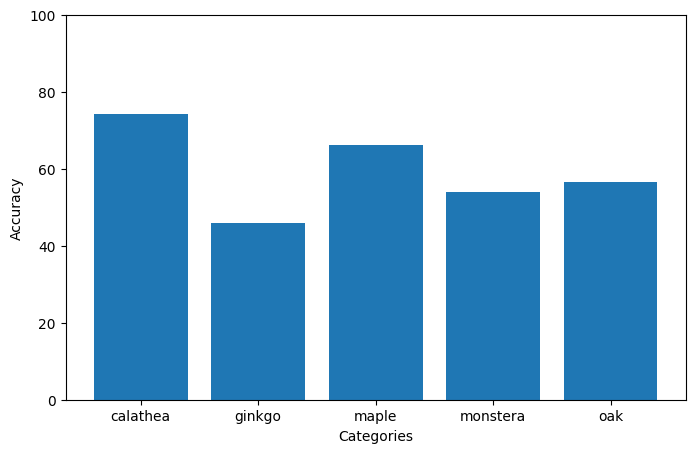

In [30]:
num_classes = 5
correct_per_class = [0] * num_classes
total_per_class = [0] * num_classes

with torch.no_grad():
  for images, labels in test_loader:
    # Move images and labels to the device
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

    for i in range(labels.size(0)):
        label = labels[i].item()
        total_per_class[label] += 1
        if predicted[i] == label:
            correct_per_class[label] += 1
accuracy_per_class = [100 * c / t if t != 0 else 0 for c, t in zip(correct_per_class, total_per_class)]

import matplotlib.pyplot as plt
import numpy as np

classes = ['calathea', 'ginkgo', 'maple', 'monstera', 'oak']  # Replace with your real category names

plt.figure(figsize=(8, 5))
plt.bar(classes, accuracy_per_class)
plt.xlabel("Categories")
plt.ylabel("Accuracy")
plt.ylim(0, 100)

plt.show()